# Round 2: Logistic Regression


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

sns.set(style='whitegrid')
reports_dir = '/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/reports'
os.makedirs(reports_dir, exist_ok=True)

In [ ]:
train_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/train.xlsx')
val_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/val.xlsx')
X_train = train_df['cleaned_poem'].astype(str)
X_val = val_df['cleaned_poem'].astype(str)
y_train_p = train_df['primary_id']
y_val_p = val_df['primary_id']
y_train_s = train_df['secondary_id']
y_val_s = val_df['secondary_id']
with open('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/label_maps.json', 'r') as f:
    maps = json.load(f)
p_map = {v: k for k, v in maps['primary_map'].items()}
s_map = {v: k for k, v in maps['secondary_map'].items()}

In [ ]:
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

In [ ]:
def train_evaluate(y_train, y_val, label_map, prefix):
    print(f"\nTraining LR for {prefix}...")
    model = LogisticRegression(class_weight='balanced', multi_class='multinomial', max_iter=2000, n_jobs=1)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_val_vec)
    
    acc = accuracy_score(y_val, y_pred)
    f1_w = f1_score(y_val, y_pred, average='weighted')
    prec_w = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1_w:.4f}")
    print(f"Weighted Precision: {prec_w:.4f}")
    print(f"Weighted Recall: {rec_w:.4f}")
    
    metrics = {'accuracy': acc, 'weighted_f1': f1_w, 'weighted_precision': prec_w, 'weighted_recall': rec_w}
    with open(f'{reports_dir}/{prefix}_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=4)
        
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Greens', fmt='d')
    plt.title(f'{prefix} LR Confusion Matrix')
    plt.savefig(f'{reports_dir}/{prefix}_confusion_matrix.png')
    plt.show()
    
    res = pd.DataFrame({'True': y_val, 'Pred': y_pred})
    res['True_Label'] = res['True'].map(label_map)
    res['Pred_Label'] = res['Pred'].map(label_map)
    res[res['True'] != res['Pred']].to_csv(f'{reports_dir}/{prefix}_errors.csv', index=False)


Training LR for primary_lr...


/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.3394
Weighted F1: 0.3226
Weighted Precision: 0.4133
Weighted Recall: 0.3394


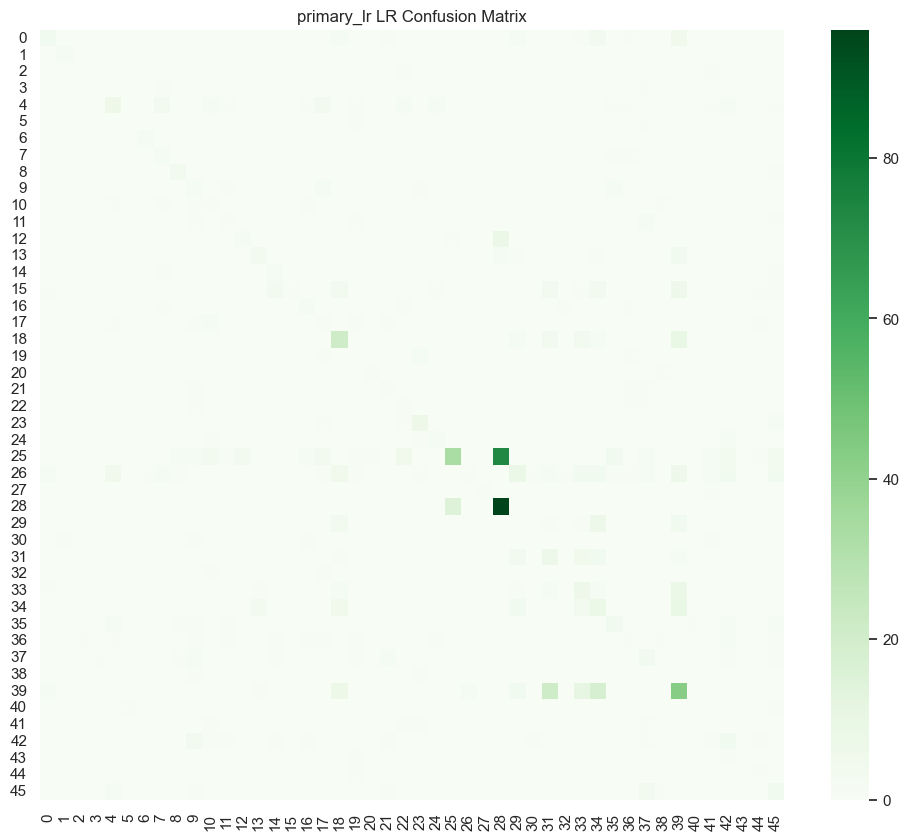

In [ ]:
train_evaluate(y_train_p, y_val_p, p_map, 'primary_lr')


Training LR for secondary_lr...


/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.2145
Weighted F1: 0.1681
Weighted Precision: 0.2028
Weighted Recall: 0.2145


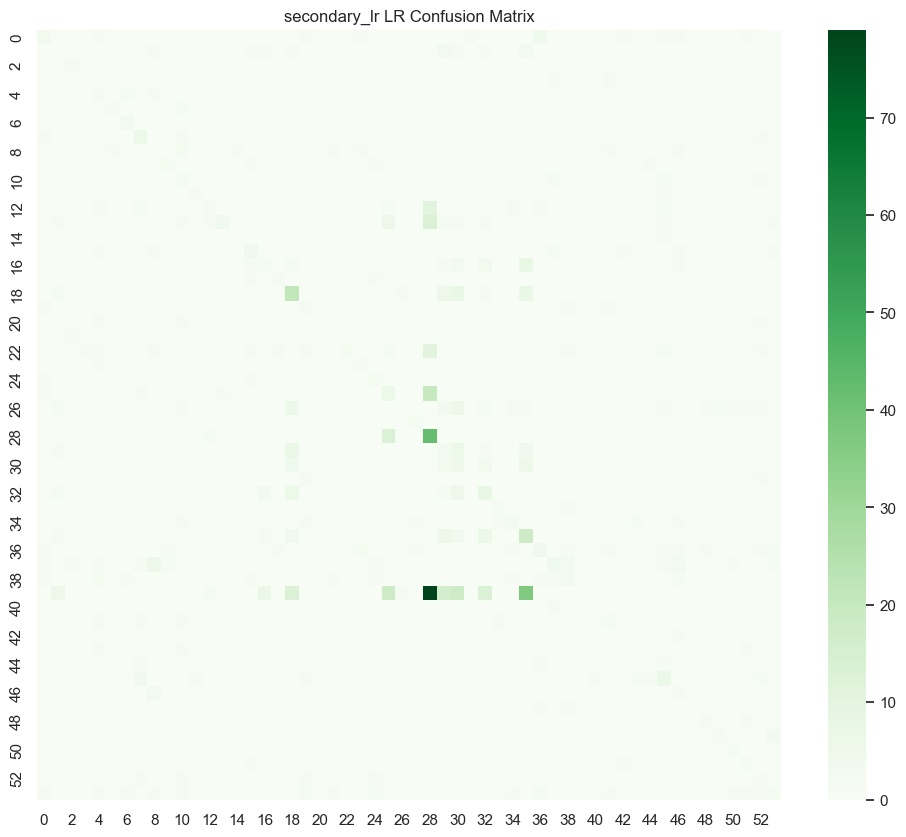

In [ ]:
train_evaluate(y_train_s, y_val_s, s_map, 'secondary_lr')